# Atlas 14 Gridded Design Storm Rain-on-Grid in HEC-RAS

This engineer-facing workflow converts spatial NOAA Atlas 14 precipitation-frequency depths into an Alternating Block Method (ABM) design storm, authors HEC-RAS-compatible gridded precipitation, executes three controlled Bald Eagle Creek scenarios, and compares the modeled hydraulic response.

The comparison isolates spatial pattern: a no-rain baseline, a spatial Atlas 14 ABM, and a uniform control with the same mesh-area-weighted temporal forcing. The resulting increases and decreases are calculated model outputs for professional review, not conclusions about net benefit, adverse impact, or causation.

## Scope, controls, and constraints

- **Canonical data:** NOAA Atlas 14 precipitation-frequency grids delivered through the NOAA/NWS Hydrometeorological Design Studies Center.
- **Canonical model:** the USACE Bald Eagle meteorological-data workshop model, Plan 06, geometry g09, and unsteady flow u03.
- **Design storm:** 100-year, 24-hour precipitation depth; 15-minute ABM blocks centered at 50% of storm duration.
- **Five-day forcing:** the 24-hour storm is followed by explicit zero-rate frames at the established 15-minute timestep through the five-day plan end. This preserves the complete storm and does not add precipitation depth.
- **Controls:** inherited boundary conditions, geometry, terrain, infiltration, and computational settings remain unchanged among scenarios.
- **Gate assumption:** the source project contains a time-series-controlled Sayers Dam gate schedule fixed at 2.0 ft. It is preserved as an analytical assumption because observed design-storm gate operations are unavailable.
- **Uniform comparison:** the uniform grid preserves the spatial scenario's mesh-area-weighted rate at every timestep. It is not a lower- or higher-rainfall sensitivity.

Official references: [NOAA PFDS](https://hdsc.nws.noaa.gov/pfds/), [NOAA GIS grids](https://hdsc.nws.noaa.gov/pfds/pfds_gis.html), and the [USACE HEC-RAS Meteorological Data workshop](https://www.hec.usace.army.mil/confluence/rasdocs/hgt/latest/tutorials/2d-unsteady-flow/meteorological-data).

In [1]:
# True uses this checkout; False uses the installed package.
USE_LOCAL_SOURCE = True

import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if REPO_ROOT.name.lower() == "examples":
    REPO_ROOT = REPO_ROOT.parent

if USE_LOCAL_SOURCE:
    local_path = str(REPO_ROOT)
    if local_path not in sys.path:
        sys.path.insert(0, local_path)
    print("LOCAL SOURCE MODE")
else:
    print("PIP PACKAGE MODE")


LOCAL SOURCE MODE


In [2]:
from __future__ import annotations

from datetime import datetime
import os
import re
from time import perf_counter

import geopandas as gpd
import h5py
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import array_bounds
import xarray as xr

from ras_commander import RasCmdr, RasExamples, RasPlan, RasUnsteady, init_ras_project
from ras_commander.hdf import HdfMesh, HdfResultsMesh, HdfResultsPlan, HdfStruc
from ras_commander.precip import AbmHyetographGrid, Atlas14Grid
from ras_commander.results import ResultsParser

RUN_ROOT = Path(
    os.environ.get(
        "RAS_COMMANDER_EXAMPLE_RUN_ROOT",
        REPO_ROOT / "working" / "example_727_atlas14_gridded_rain_on_grid",
    )
)
RUN_ROOT.mkdir(parents=True, exist_ok=True)

PROJECT_NAME = "BaldEagleCrkMulti2D"
PROJECT_SUFFIX = "atlas14_727"
RAS_VERSION = "7.0"
SOURCE_PLAN = "06"
SOURCE_GEOMETRY = "09"
SOURCE_UNSTEADY = "03"
GATE_STRUCTURE_NAME = "Sayers Dam"

ARI_YEARS = 100
STORM_DURATION_HOURS = 24.0
TIMESTEP_MINUTES = 15
PEAK_POSITION_PERCENT = 50.0
ATLAS_BUFFER_PERCENT = 10.0
DDF_DURATIONS = [1, 2, 3, 6, 12, 24]
OUTPUT_VARIABLE = "APCP_surface"
REPORTING_THRESHOLD_FT = 0.01

COLORS = {
    "navy": "#174A6E",
    "blue": "#2D7FA3",
    "gold": "#D39A2C",
    "red": "#B64C3B",
    "green": "#477A5B",
    "gray": "#5C6670",
}
plt.rcParams.update({"figure.dpi": 120, "axes.grid": False})
print(f"Run workspace: {RUN_ROOT.name}")


Run workspace: example_727_atlas14_gridded_rain_on_grid


## 1. Initialize the canonical Bald Eagle model

Project and plan selection are driven by ras-commander DataFrames. The notebook does not discover model files with arbitrary glob patterns.


In [3]:
project_path = RasExamples.extract_project(
    "BaldEagleCrkMulti2D",
    output_path=RUN_ROOT,
    suffix=PROJECT_SUFFIX,
)
ras = init_ras_project(
    project_path,
    ras_version=RAS_VERSION,
    load_results_summary=False,
)

plan_number = ras.plan_df["plan_number"].astype(str).str.zfill(2)
source_rows = ras.plan_df.loc[plan_number.eq(SOURCE_PLAN)]
assert len(source_rows) == 1, "Expected exactly one source Plan 06"
source_plan = source_rows.iloc[0]

assert str(source_plan["geometry_number"]).zfill(2) == SOURCE_GEOMETRY
assert str(source_plan["unsteady_number"]).zfill(2) == SOURCE_UNSTEADY

GEOMETRY_HDF = Path(f"{source_plan['Geom Path']}.hdf")
assert GEOMETRY_HDF.exists(), f"Geometry HDF is required: {GEOMETRY_HDF}"

date_parts = str(source_plan["Simulation Date"]).split(",")
SIM_START = datetime.strptime(
    f"{date_parts[0]} {date_parts[1]}", "%d%b%Y %H%M"
)
SIM_END = datetime.strptime(
    f"{date_parts[2]} {date_parts[3]}", "%d%b%Y %H%M"
)
SIMULATION_HOURS = (SIM_END - SIM_START).total_seconds() / 3600.0
assert SIMULATION_HOURS == 120.0

model_selection = pd.DataFrame(
    [{
        "project": ras.project_name,
        "HEC-RAS version": RAS_VERSION,
        "source plan": f"p{SOURCE_PLAN}",
        "geometry": f"g{SOURCE_GEOMETRY}",
        "unsteady flow": f"u{SOURCE_UNSTEADY}",
        "simulation start": SIM_START,
        "simulation end": SIM_END,
        "duration (hr)": SIMULATION_HOURS,
        "computation interval": source_plan["Computation Interval"],
        "mapping interval": source_plan["Mapping Interval"],
    }]
)
display(model_selection)


2026-07-13 14:12:36 - ras_commander.RasExamples - INFO - Successfully extracted project 'BaldEagleCrkMulti2D' to BaldEagleCrkMulti2D_atlas14_727


2026-07-13 14:12:37 - ras_commander.RasPrj - INFO - ras-commander v0.98.2 | An open-source project of CLB Engineering Corporation (https://clbengineering.com/) | Docs: https://rascommander.info | GitHub: https://github.com/gpt-cmdr/ras-commander


2026-07-13 14:12:37 - ras_commander.RasPrj - INFO - Project initialized: BaldEagleDamBrk


2026-07-13 14:12:37 - ras_commander.RasPrj - INFO - Using HEC-RAS version 7.0


2026-07-13 14:12:37 - ras_commander.RasPrj - INFO - 
═══════════════════════════════════════════════════════════════════════
ras-commander | HEC-RAS Automation Library
Docs: https://rascommander.info/
Repo: https://github.com/gpt-cmdr/ras-commander
LLM agents: https://rascommander.info/llms.txt
═══════════════════════════════════════════════════════════════════════

PROJECT DATAFRAMES (single source of truth — use these, not file globbing):
  ras.plan_df        Plans, HDF paths, geometry/flow associations
  ras.geom_df        Geometry files and HDF preprocessor paths
  ras.flow_df        Steady flow files
  ras.unsteady_df    Unsteady flow files and configurations
  ras.boundaries_df  Boundary conditions (type, name, location)
  ras.results_df     Lightweight HDF results summaries
  ras.rasmap_df      RASMapper layers, terrain, land cover paths

KEY APIS (static classes — call directly, never instantiate):
  Execution:    RasCmdr.compute_plan() / compute_parallel() / compute_test_mode(

,project,HEC-RAS version,source plan,geometry,unsteady flow,simulation start,simulation end,duration (hr),computation interval,mapping interval
0,BaldEagleDamBrk,7.0,p06,g09,u03,2018-09-09,2018-09-14,120.0,20SEC,10MIN


## 2. Model context and inherited conditions

The source plan already combines a 2D domain, terrain, infiltration, upstream inflow, two normal-depth outlets, and the internal Sayers Dam gate. The following checks establish that the non-precipitation inputs cover the five-day plan before any scenarios are cloned.


In [4]:
def first_rasmap_path(column: str) -> Path | None:
    value = ras.rasmap_df.iloc[0][column]
    if isinstance(value, (list, tuple)):
        value = value[0] if value else None
    return Path(value) if value else None


def interval_hours(interval: str) -> float:
    match = re.fullmatch(r"\s*(\d+)\s*(MIN|HOUR)\s*", str(interval).upper())
    if not match:
        raise ValueError(f"Unsupported interval for audit: {interval!r}")
    value, unit = int(match.group(1)), match.group(2)
    return value / 60.0 if unit == "MIN" else float(value)


layer_specs = [
    ("Projection", first_rasmap_path("projection_path")),
    ("Terrain", first_rasmap_path("terrain_hdf_path")),
    ("Infiltration", first_rasmap_path("infiltration_hdf_path")),
    ("Hydrologic soil group", first_rasmap_path("soil_layer_path")),
    ("Land cover", first_rasmap_path("landcover_hdf_path")),
]
layer_audit = pd.DataFrame(
    [
        {
            "model layer": label,
            "file": path.name if path else None,
            "available": bool(path and path.exists()),
        }
        for label, path in layer_specs
    ]
)
assert layer_audit["available"].all(), "A required RASMapper model layer is missing"

source_boundaries = ras.boundaries_df.loc[
    ras.boundaries_df["unsteady_number"].astype(str).str.zfill(2).eq(SOURCE_UNSTEADY)
].copy()
assert set(source_boundaries["bc_type"]) >= {
    "Flow Hydrograph",
    "Normal Depth",
    "Gate Opening",
}

boundary_records = []
for _, row in source_boundaries.iterrows():
    if row["bc_type"] == "Flow Hydrograph":
        count = int(row["hydrograph_num_values"])
        coverage = count * interval_hours(row["Interval"])
        detail = f"{count} values at {row['Interval']}"
    elif row["bc_type"] == "Normal Depth":
        coverage = np.inf
        detail = f"friction slope = {float(row['friction_slope_value']):.4f}"
    else:
        continue
    boundary_records.append(
        {
            "boundary": row["bc_line_name"] or row["bc_type"],
            "type": row["bc_type"],
            "configuration": detail,
            "coverage (hr)": coverage,
            "covers plan": coverage >= SIMULATION_HOURS,
        }
    )

gate = RasUnsteady.get_gate_openings(
    SOURCE_UNSTEADY,
    boundary_index=0,
    ras_object=ras,
)
gate_coverage = gate["count"] * interval_hours(gate["interval"])
assert gate["gate_name"] == "Gate #1"
assert gate["count"] == len(gate["values"]) == 100
assert np.allclose(gate["values"], 2.0)
boundary_records.append(
    {
        "boundary": f"{GATE_STRUCTURE_NAME} / {gate['gate_name']}",
        "type": "Time-series gate opening",
        "configuration": f"{gate['count']} values at {gate['interval']}; all 2.0 ft",
        "coverage (hr)": gate_coverage,
        "covers plan": gate_coverage >= SIMULATION_HOURS,
    }
)

boundary_audit = pd.DataFrame(boundary_records)
assert boundary_audit["covers plan"].all()
display(layer_audit)
display(boundary_audit)


,model layer,file,available
0,Projection,Projection.prj,True
1,Terrain,Terrain50.hdf,True
2,Infiltration,Infiltration.hdf,True
3,Hydrologic soil group,Hydrologic Soil Groups.hdf,True
4,Land cover,LandCover.hdf,True


,boundary,type,configuration,coverage (hr),covers plan
0,DSNormalDepth,Normal Depth,friction slope = 0.0003,inf,True
1,Upstream Inflow,Flow Hydrograph,1000 values at 1HOUR,1000.0,True
2,DS2NormalD,Normal Depth,friction slope = 0.0003,inf,True
3,Sayers Dam / Gate #1,Time-series gate opening,100 values at 6HOUR; all 2.0 ft,600.0,True


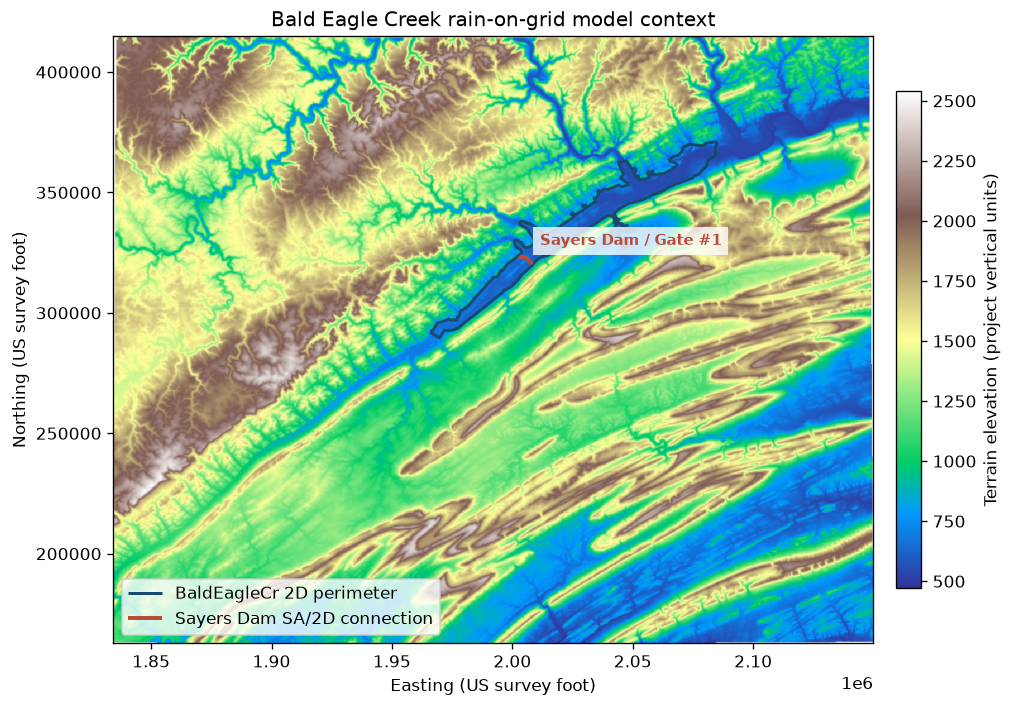

,2D area,mesh cells,terrain,infiltration,land cover,source gate,gate opening assumption (ft)
0,BaldEagleCr,18066,Terrain50.vrt,Infiltration.hdf,LandCover.hdf,Sayers Dam / Gate #1,2.0


In [5]:
mesh_areas = HdfMesh.get_mesh_areas(GEOMETRY_HDF)
mesh_cells = HdfMesh.get_mesh_cell_polygons(GEOMETRY_HDF)
structures = HdfStruc.get_structures(GEOMETRY_HDF)
assert not mesh_areas.empty and not mesh_cells.empty
assert mesh_areas.crs is not None and mesh_cells.crs is not None
mesh_names = mesh_areas["mesh_name"].dropna().astype(str).unique().tolist()
assert len(mesh_names) == 1, f"Expected one 2D flow area, found {mesh_names}"
MESH_NAME = mesh_names[0]
sayers_dam = structures.loc[structures["Connection"].eq(GATE_STRUCTURE_NAME)].copy()
assert len(sayers_dam) == 1, "Expected one Sayers Dam SA/2D connection"

terrain_hdf = first_rasmap_path("terrain_hdf_path")
terrain_vrt = terrain_hdf.with_suffix(".vrt")
assert terrain_vrt.exists(), f"Terrain VRT referenced by {terrain_hdf.name} is missing"

with rasterio.open(terrain_vrt) as terrain_source:
    scale = max(1, int(max(terrain_source.height, terrain_source.width) / 1200))
    out_height = max(1, terrain_source.height // scale)
    out_width = max(1, terrain_source.width // scale)
    terrain = terrain_source.read(
        1,
        out_shape=(out_height, out_width),
        masked=True,
    )
    terrain_transform = terrain_source.transform * terrain_source.transform.scale(
        terrain_source.width / out_width,
        terrain_source.height / out_height,
    )
    terrain_bounds = array_bounds(out_height, out_width, terrain_transform)
    terrain_crs = terrain_source.crs

mesh_on_terrain = mesh_areas.to_crs(terrain_crs)
sayers_on_terrain = sayers_dam.to_crs(terrain_crs)
left, bottom, right, top = terrain_bounds

fig, ax = plt.subplots(figsize=(10, 6))
image = ax.imshow(
    terrain,
    extent=(left, right, bottom, top),
    origin="upper",
    cmap="terrain",
)
mesh_on_terrain.boundary.plot(
    ax=ax,
    color=COLORS["navy"],
    linewidth=1.8,
    label="BaldEagleCr 2D perimeter",
)
sayers_on_terrain.plot(
    ax=ax,
    color=COLORS["red"],
    linewidth=2.4,
    label="Sayers Dam SA/2D connection",
)
dam_label_point = sayers_on_terrain.geometry.iloc[0].interpolate(0.5, normalized=True)
ax.annotate(
    "Sayers Dam / Gate #1",
    xy=(dam_label_point.x, dam_label_point.y),
    xytext=(8, 8),
    textcoords="offset points",
    color=COLORS["red"],
    fontsize=9,
    fontweight="bold",
    bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8},
)
ax.set_title("Bald Eagle Creek rain-on-grid model context")
ax.set_xlabel(f"Easting ({terrain_crs.linear_units})")
ax.set_ylabel(f"Northing ({terrain_crs.linear_units})")
ax.legend(loc="lower left", frameon=True)
colorbar = fig.colorbar(image, ax=ax, shrink=0.82, pad=0.02)
colorbar.set_label("Terrain elevation (project vertical units)")
fig.tight_layout()
plt.show()

context_summary = pd.DataFrame(
    [{
        "2D area": ", ".join(mesh_areas["mesh_name"].astype(str)),
        "mesh cells": len(mesh_cells),
        "terrain": terrain_vrt.name,
        "infiltration": first_rasmap_path("infiltration_hdf_path").name,
        "land cover": first_rasmap_path("landcover_hdf_path").name,
        "source gate": f"{GATE_STRUCTURE_NAME} / {gate['gate_name']}",
        "gate opening assumption (ft)": float(gate["values"][0]),
    }]
)
display(context_summary)


### Operational assumption

USACE identifies the dam in this workshop model as an SA/2D Connection with time-series-controlled gate openings. The unsteady boundary references the **Sayers Dam** connection, and the gate API identifies **Gate #1** with 100 six-hour values, all equal to **2.0 ft**. This notebook preserves that schedule exactly.

The 2.0 ft schedule is inherited model input, not observed operation data for a 100-year design storm. Any engineering application should replace it with an approved operating rule or observed schedule and test gate-operation sensitivity.


## 3. Retrieve Atlas 14 depths and verify spatial variability

Atlas14Grid reads only the project subset required for the 2D area plus a 10% buffer. Six durations are retained for the depth-duration-frequency check; the 24-hour, 100-year grid defines the storm total at each pixel.


In [6]:
atlas = Atlas14Grid.get_pfe_from_project(
    GEOMETRY_HDF,
    extent_source="2d_flow_area",
    durations=DDF_DURATIONS,
    return_periods=[ARI_YEARS],
    buffer_percent=ATLAS_BUFFER_PERCENT,
)
assert atlas["units"] == "inches"
assert atlas["extent_source"] == "2d_flow_area"
assert atlas["mesh_area_names"] == mesh_areas["mesh_name"].astype(str).tolist()

ari_values = np.asarray(atlas["ari"], dtype=float)
ari_matches = np.flatnonzero(np.isclose(ari_values, ARI_YEARS))
assert len(ari_matches) == 1
ari_index = int(ari_matches[0])

depth_grids = {
    duration: np.asarray(atlas[f"pfe_{duration}hr"])[:, :, ari_index]
    for duration in DDF_DURATIONS
}
depth_24hr = depth_grids[24]
assert np.isfinite(depth_24hr).all()
assert float(np.nanmin(depth_24hr)) > 0.0

flat_24hr = depth_24hr.ravel()
median_flat_index = int(np.nanargmin(np.abs(flat_24hr - np.nanmedian(flat_24hr))))
representative_indices = {
    "Minimum-depth pixel": np.unravel_index(np.nanargmin(flat_24hr), depth_24hr.shape),
    "Median-depth pixel": np.unravel_index(median_flat_index, depth_24hr.shape),
    "Maximum-depth pixel": np.unravel_index(np.nanargmax(flat_24hr), depth_24hr.shape),
}

atlas_summary = pd.DataFrame(
    [{
        "return period (yr)": ARI_YEARS,
        "duration (hr)": STORM_DURATION_HOURS,
        "grid rows": depth_24hr.shape[0],
        "grid columns": depth_24hr.shape[1],
        "minimum depth (in)": float(np.nanmin(depth_24hr)),
        "mean depth (in)": float(np.nanmean(depth_24hr)),
        "maximum depth (in)": float(np.nanmax(depth_24hr)),
        "max/min ratio": float(np.nanmax(depth_24hr) / np.nanmin(depth_24hr)),
    }]
)
display(atlas_summary.round(3))


2026-07-13 14:12:39 - ras_commander.precip.Atlas14Grid - INFO - Extracting Atlas 14 extent from BaldEagleDamBrk.g09.hdf using 2d_flow_area


2026-07-13 14:12:39 - ras_commander.precip.Atlas14Grid - INFO - 2D flow area bounds: W=-77.7591, S=40.9614, E=-77.3275, N=41.1842


2026-07-13 14:12:39 - ras_commander.precip.Atlas14Grid - INFO - Loading Atlas 14 coordinate arrays from remote file...


2026-07-13 14:12:55 - ras_commander.precip.Atlas14Grid - INFO - Loaded coordinates: lat=3121, lon=7081, ari=9


2026-07-13 14:12:55 - ras_commander.precip.Atlas14Grid - INFO - Extracting Atlas 14 data for bounds (-77.8023, 40.9392, -77.2844, 41.2064): lat[2033:2065], lon[5664:5726]


2026-07-13 14:13:22 - ras_commander.precip.Atlas14Grid - INFO - Atlas 14 subset: 209.2 KB of 2276.2 MB estimated full-grid payload (32x62 cells, 6 durations, 0.00898% of full grid)


,return period (yr),duration (hr),grid rows,grid columns,minimum depth (in),mean depth (in),maximum depth (in),max/min ratio
0,100,24.0,32,62,5.6,6.005,7.43,1.327


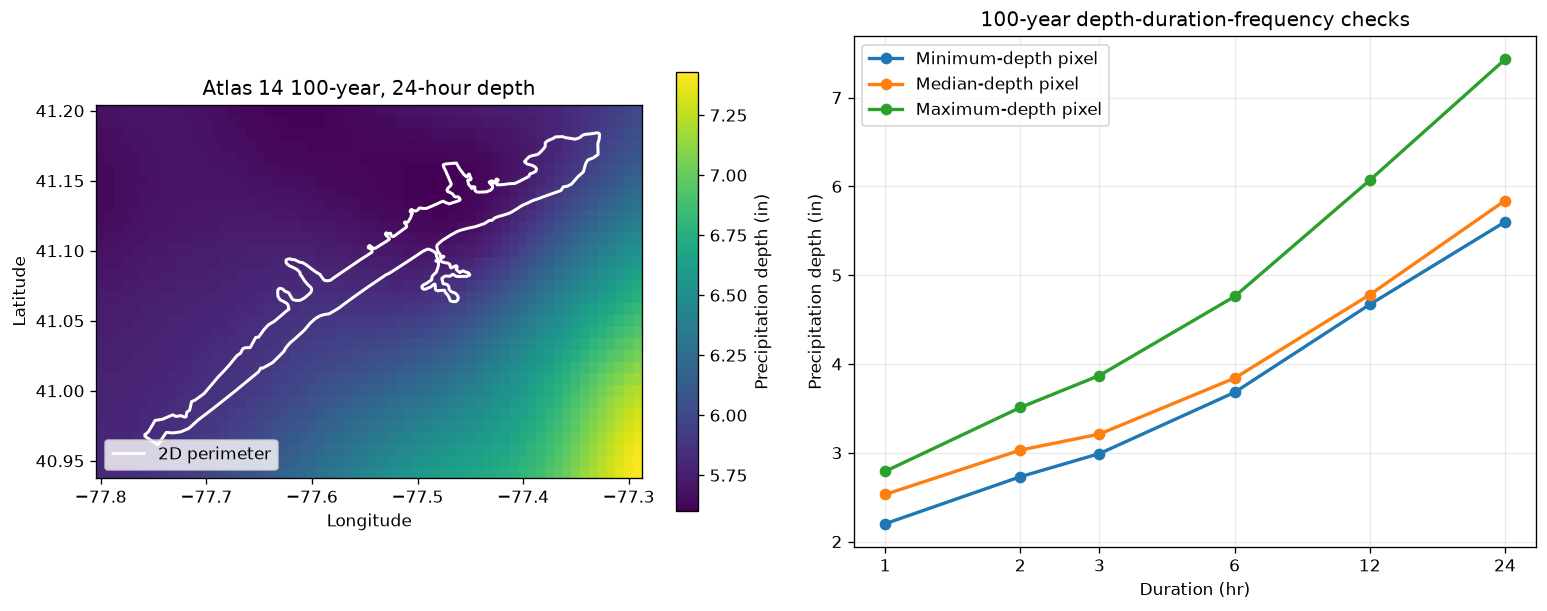

In [7]:
mesh_lonlat = mesh_areas.to_crs("EPSG:4326")
lat = np.asarray(atlas["lat"], dtype=float)
lon = np.asarray(atlas["lon"], dtype=float)

fig, (map_ax, ddf_ax) = plt.subplots(1, 2, figsize=(13, 5.2))

depth_image = map_ax.pcolormesh(
    lon,
    lat,
    depth_24hr,
    shading="auto",
    cmap="viridis",
)
mesh_lonlat.boundary.plot(
    ax=map_ax,
    color="white",
    linewidth=1.8,
    label="2D perimeter",
)
map_ax.set_title("Atlas 14 100-year, 24-hour depth")
map_ax.set_xlabel("Longitude")
map_ax.set_ylabel("Latitude")
map_ax.legend(loc="lower left")
map_colorbar = fig.colorbar(depth_image, ax=map_ax, shrink=0.86)
map_colorbar.set_label("Precipitation depth (in)")

for label, (row, col) in representative_indices.items():
    values = [depth_grids[duration][row, col] for duration in DDF_DURATIONS]
    assert np.all(np.diff(values) > 0.0)
    ddf_ax.plot(
        DDF_DURATIONS,
        values,
        marker="o",
        linewidth=2,
        label=label,
    )
ddf_ax.set_xscale("log", base=2)
ddf_ax.set_xticks(DDF_DURATIONS, labels=[str(value) for value in DDF_DURATIONS])
ddf_ax.set_title("100-year depth-duration-frequency checks")
ddf_ax.set_xlabel("Duration (hr)")
ddf_ax.set_ylabel("Precipitation depth (in)")
ddf_ax.grid(True, alpha=0.25)
ddf_ax.legend(loc="upper left")

fig.tight_layout()
plt.show()


## 4. Construct and verify the spatial ABM storm

The ABM rearranges incremental depths from each pixel's duration curve into a centered 15-minute design hyetograph. It does not alter the 24-hour Atlas depth. The raw design-storm file remains in WGS84 with relative times and incremental inches so that those assumptions can be inspected directly.


In [8]:
precipitation_dir = ras.project_folder / "Precipitation" / "atlas14_727"
precipitation_dir.mkdir(parents=True, exist_ok=True)

RAW_ABM = precipitation_dir / "atlas14_100yr_24hr_abm_raw.nc"
SPATIAL_RAS_NETCDF = precipitation_dir / "atlas14_100yr_24hr_abm_ras.nc"
UNIFORM_RAS_NETCDF = precipitation_dir / "atlas14_100yr_24hr_uniform_ras.nc"

raw_abm_path = AbmHyetographGrid.generate(
    bounds=atlas["bounds"],
    ari_years=ARI_YEARS,
    storm_duration_hours=STORM_DURATION_HOURS,
    timestep_minutes=TIMESTEP_MINUTES,
    peak_position_percent=PEAK_POSITION_PERCENT,
    output_netcdf=RAW_ABM,
    buffer_percent=0.0,
    include_subhourly=True,
)
assert raw_abm_path.exists()

with xr.open_dataset(
    raw_abm_path,
    engine="netcdf4",
    decode_timedelta=False,
) as raw_source:
    raw_abm = raw_source.load()

increments_in = raw_abm["precip_incremental"]
cumulative_in = raw_abm["precip_cumulative"]
assert increments_in.dims == ("time", "lat", "lon")
assert increments_in.sizes["time"] == 96
assert increments_in.attrs["units"] == "inches"
assert np.allclose(np.diff(raw_abm["time"].values), TIMESTEP_MINUTES / 60.0)

abm_total_in = increments_in.sum("time")
atlas_total_on_abm_grid = xr.DataArray(
    depth_24hr,
    dims=("lat", "lon"),
    coords={"lat": atlas["lat"], "lon": atlas["lon"]},
)
atlas_total_on_abm_grid = atlas_total_on_abm_grid.sel(
    lat=abm_total_in["lat"],
    lon=abm_total_in["lon"],
)
abm_depth_error_in = np.abs(abm_total_in - atlas_total_on_abm_grid)
assert float(abm_depth_error_in.max()) <= 1e-5

abm_qc = pd.DataFrame(
    [{
        "intervals": increments_in.sizes["time"],
        "interval (min)": TIMESTEP_MINUTES,
        "storm duration (hr)": increments_in.sizes["time"] * TIMESTEP_MINUTES / 60.0,
        "peak position (%)": PEAK_POSITION_PERCENT,
        "minimum total (in)": float(abm_total_in.min()),
        "mean total (in)": float(abm_total_in.mean()),
        "maximum total (in)": float(abm_total_in.max()),
        "max Atlas-vs-ABM error (in)": float(abm_depth_error_in.max()),
    }]
)
display(abm_qc.round(6))


2026-07-13 14:13:22 - ras_commander.precip.AbmHyetographGrid - INFO - Generating ABM grid: ARI=100yr, duration=24.0hr, dt=15min, peak@50.0%, bounds=(np.float64(-77.80227796999864), np.float64(40.939176433913076), np.float64(-77.28436563242954), np.float64(41.20644561999805))


2026-07-13 14:13:22 - ras_commander.precip.Atlas14Grid - INFO - Extracting Atlas 14 data for bounds (-77.8023, 40.9392, -77.2844, 41.2064): lat[2033:2065], lon[5664:5726]


2026-07-13 14:13:55 - ras_commander.precip.Atlas14Grid - INFO - Atlas 14 subset: 244.1 KB of 2655.6 MB estimated full-grid payload (32x62 cells, 7 durations, 0.00898% of full grid)


2026-07-13 14:13:55 - ras_commander.precip.StormGenerator - INFO - Downloading Atlas 14 data for (41.07281102695556, -77.54332180121409)...


2026-07-13 14:13:57 - ras_commander.precip.StormGenerator - INFO - Downloaded Atlas 14 data for region: Ohio River Basin


2026-07-13 14:13:57 - ras_commander.precip.AbmHyetographGrid - INFO - ABM grid complete → atlas14_100yr_24hr_abm_raw.nc


,intervals,interval (min),storm duration (hr),peak position (%),minimum total (in),mean total (in),maximum total (in),max Atlas-vs-ABM error (in)
0,96,15,24.0,50.0,5.599998,6.005237,7.429999,0.000003


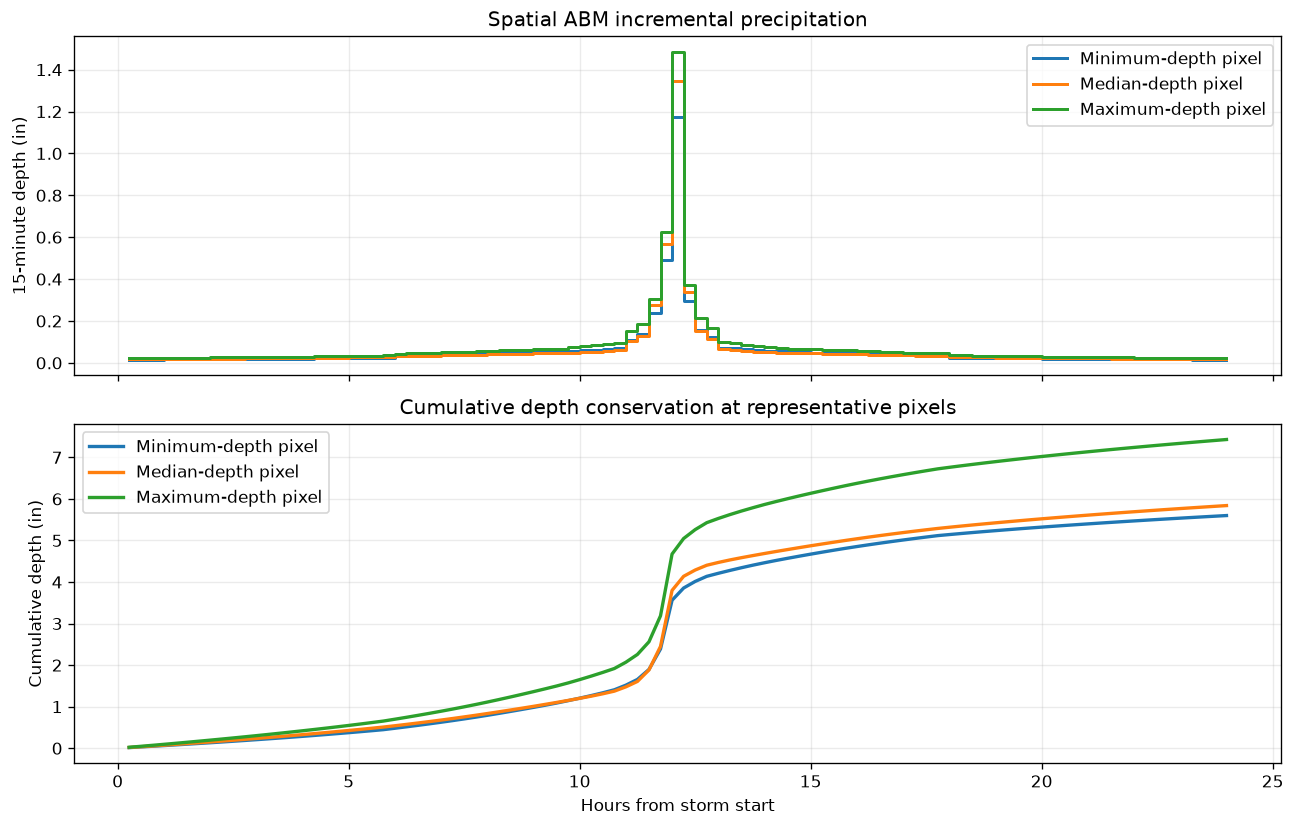

In [9]:
interval_end_hours = (
    np.asarray(raw_abm["time"].values, dtype=float)
    + TIMESTEP_MINUTES / 60.0
)

fig, (increment_ax, cumulative_ax) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for label, (row, col) in representative_indices.items():
    incremental_series = increments_in.isel(lat=row, lon=col).values
    cumulative_series = cumulative_in.isel(lat=row, lon=col).values
    increment_ax.step(
        interval_end_hours,
        incremental_series,
        where="post",
        linewidth=1.8,
        label=label,
    )
    cumulative_ax.plot(
        interval_end_hours,
        cumulative_series,
        linewidth=2,
        label=label,
    )

increment_ax.set_title("Spatial ABM incremental precipitation")
increment_ax.set_ylabel("15-minute depth (in)")
increment_ax.grid(True, alpha=0.25)
increment_ax.legend(loc="upper right")

cumulative_ax.set_title("Cumulative depth conservation at representative pixels")
cumulative_ax.set_xlabel("Hours from storm start")
cumulative_ax.set_ylabel("Cumulative depth (in)")
cumulative_ax.grid(True, alpha=0.25)
cumulative_ax.legend(loc="upper left")

fig.tight_layout()
plt.show()


## 5. Convert to the HEC-RAS GDAL NetCDF contract

The conversion changes representation, not rainfall depth:

1. incremental inches become interval-ending rates in mm/hr;
2. a zero-rate frame is inserted at the simulation start;
3. relative hours become absolute timestamps;
4. WGS84 latitude/longitude is projected to EPSG:5070 x/y;
5. the recognized APCP_surface variable and CF metadata are written; and
6. aligned zero-rate frames extend forcing coverage from the natural storm end through the exact plan end.

The conversion independently reprojects cumulative depth, fails if the projected rate integration does not conserve it, and records separate `storm_end` and `forcing_end` metadata.

In [10]:
spatial_path = AbmHyetographGrid.to_ras_netcdf(
    raw_abm_path,
    SPATIAL_RAS_NETCDF,
    start_time=SIM_START,
    target_crs="EPSG:5070",
    output_variable=OUTPUT_VARIABLE,
    end_time=SIM_END,
)
assert spatial_path.exists()

with xr.open_dataset(spatial_path) as spatial_source:
    spatial_forcing = spatial_source.load()

spatial_rate = spatial_forcing[OUTPUT_VARIABLE]
forcing_times = pd.to_datetime(spatial_rate["time"].values)
interval_hours_value = float(spatial_forcing.attrs["interval_minutes"]) / 60.0
STORM_END = pd.Timestamp(SIM_START) + pd.Timedelta(hours=STORM_DURATION_HOURS)
storm_end_index = int(forcing_times.get_loc(STORM_END))
tail_start_index = storm_end_index + 1

storm_total_mm = spatial_rate.isel(time=slice(1, tail_start_index)).sum(
    "time",
    skipna=False,
) * interval_hours_value
forcing_total_mm = spatial_rate.isel(time=slice(1, None)).sum(
    "time",
    skipna=False,
) * interval_hours_value
spatial_total_in = forcing_total_mm / 25.4

assert forcing_times[0] == pd.Timestamp(SIM_START)
assert forcing_times[storm_end_index] == STORM_END
assert forcing_times[-1] == pd.Timestamp(SIM_END)
assert np.allclose(
    spatial_rate.isel(time=0).values[
        np.isfinite(spatial_rate.isel(time=0).values)
    ],
    0.0,
)
post_storm_rate = spatial_rate.isel(time=slice(tail_start_index, None)).values
assert post_storm_rate.shape[0] == 384
assert np.all(post_storm_rate[np.isfinite(post_storm_rate)] == 0.0)
xr.testing.assert_allclose(forcing_total_mm, storm_total_mm)

assert spatial_rate.attrs["units"] == "mm/hr"
assert spatial_rate.attrs["grid_mapping"] == "spatial_ref"
assert spatial_forcing.attrs["target_crs"] == "EPSG:5070"
assert pd.Timestamp(spatial_forcing.attrs["storm_end"]) == STORM_END
assert pd.Timestamp(spatial_forcing.attrs["forcing_end"]) == pd.Timestamp(SIM_END)
assert int(spatial_forcing.attrs["zero_tail_frames"]) == 384
assert float(spatial_forcing.attrs["zero_tail_hours"]) == 96.0
assert spatial_forcing.attrs["depth_conservation_max_error_mm"] <= 1e-4

mesh_5070 = mesh_areas.to_crs("EPSG:5070")
cells_5070 = mesh_cells.to_crs("EPSG:5070")
cell_centers_5070 = cells_5070.geometry.representative_point()
sample_x = xr.DataArray(cell_centers_5070.x.to_numpy(), dims="cell")
sample_y = xr.DataArray(cell_centers_5070.y.to_numpy(), dims="cell")
sampled_total_in = spatial_total_in.sel(
    x=sample_x,
    y=sample_y,
    method="nearest",
)
assert np.isfinite(sampled_total_in.values).all()
assert float(sampled_total_in.min()) > 0.0

forcing_qc = pd.DataFrame(
    [{
        "variable": OUTPUT_VARIABLE,
        "rate units": spatial_rate.attrs["units"],
        "CRS": spatial_forcing.attrs["target_crs"],
        "frames": spatial_rate.sizes["time"],
        "storm end": forcing_times[storm_end_index],
        "forcing end": forcing_times[-1],
        "zero-tail frames": int(spatial_forcing.attrs["zero_tail_frames"]),
        "valid grid fraction (%)": 100 * spatial_forcing.attrs["valid_coverage_fraction"],
        "mesh cells covered": int(np.isfinite(sampled_total_in.values).sum()),
        "mesh cells total": len(mesh_cells),
        "max conversion error (mm)": spatial_forcing.attrs[
            "depth_conservation_max_error_mm"
        ],
    }]
)
display(forcing_qc.round({column: 6 for column in forcing_qc.select_dtypes(include="number").columns}))


2026-07-13 14:13:58 - ras_commander.precip.AbmHyetographGrid - INFO - Prepared HEC-RAS Atlas 14 forcing atlas14_100yr_24hr_abm_ras.nc: 96 storm intervals, 384 zero-tail frames (96 hr), 50x64 cells, 71.3% valid coverage, max depth error 0.000003 mm


,variable,rate units,CRS,frames,storm end,forcing end,zero-tail frames,valid grid fraction (%),mesh cells covered,mesh cells total,max conversion error (mm)
0,APCP_surface,mm/hr,EPSG:5070,481,2018-09-10,2018-09-14,384,71.28125,18066,18066,0.000003


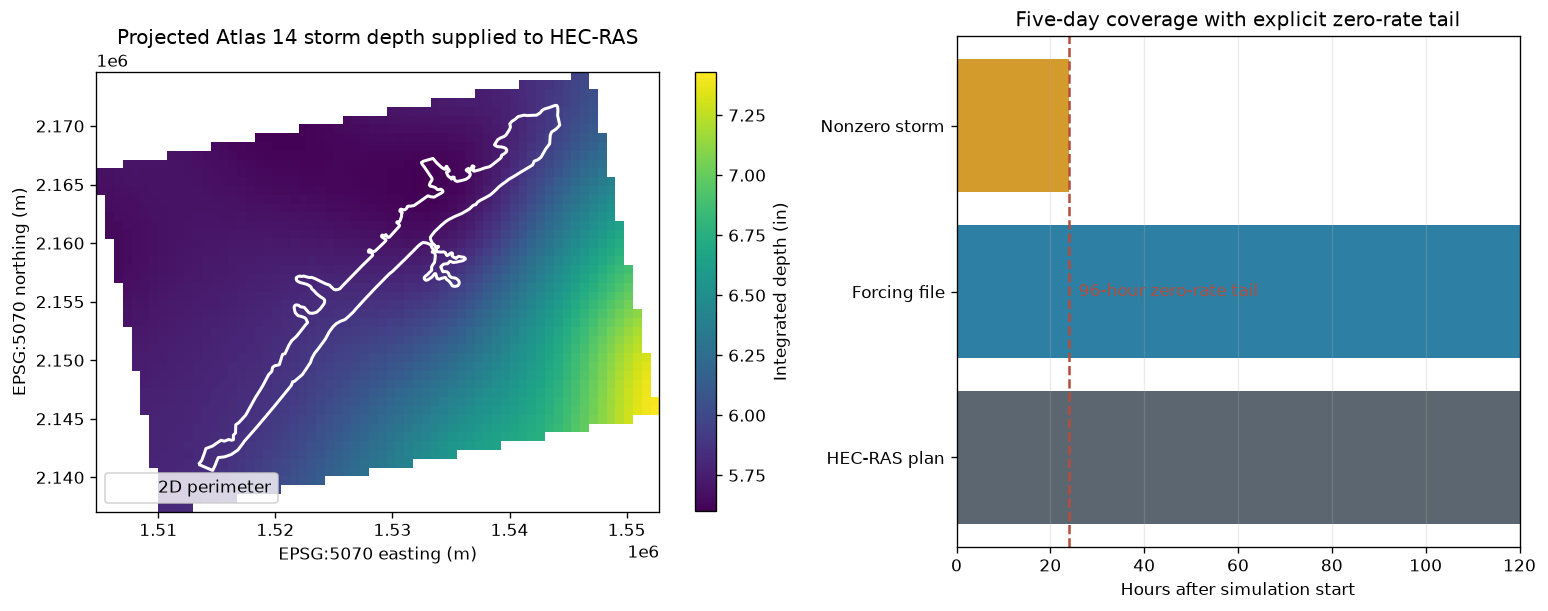

In [11]:
fig, (forcing_ax, timing_ax) = plt.subplots(
    1,
    2,
    figsize=(13, 5.2),
    gridspec_kw={"width_ratios": [1.25, 1]},
)

forcing_image = forcing_ax.pcolormesh(
    spatial_total_in["x"],
    spatial_total_in["y"],
    spatial_total_in,
    shading="auto",
    cmap="viridis",
)
mesh_5070.boundary.plot(
    ax=forcing_ax,
    color="white",
    linewidth=1.8,
    label="2D perimeter",
)
forcing_ax.set_title("Projected Atlas 14 storm depth supplied to HEC-RAS")
forcing_ax.set_xlabel("EPSG:5070 easting (m)")
forcing_ax.set_ylabel("EPSG:5070 northing (m)")
forcing_ax.legend(loc="lower left")
forcing_colorbar = fig.colorbar(forcing_image, ax=forcing_ax, shrink=0.86)
forcing_colorbar.set_label("Integrated depth (in)")

timing_ax.barh(
    ["HEC-RAS plan", "Forcing file", "Nonzero storm"],
    [SIMULATION_HOURS, SIMULATION_HOURS, STORM_DURATION_HOURS],
    color=[COLORS["gray"], COLORS["blue"], COLORS["gold"]],
)
timing_ax.axvline(
    STORM_DURATION_HOURS,
    color=COLORS["red"],
    linestyle="--",
    linewidth=1.5,
)
timing_ax.set_xlim(0, SIMULATION_HOURS)
timing_ax.set_title("Five-day coverage with explicit zero-rate tail")
timing_ax.set_xlabel("Hours after simulation start")
timing_ax.grid(True, axis="x", alpha=0.25)
timing_ax.text(
    STORM_DURATION_HOURS + 2,
    1.0,
    "96-hour zero-rate tail",
    color=COLORS["red"],
    va="center",
)

fig.tight_layout()
plt.show()


## 6. Build the equivalent-uniform spatial-pattern control

The uniform control is derived from the already extended spatial forcing after projection. At each timestep, rates are sampled at all 2D cell representative points and averaged with cell area weights. That rate is broadcast across the same valid forcing grid, including the exact zero-rate tail. This holds the mesh-area-weighted temporal volume and forcing timestamps constant while removing spatial variation.

In [12]:
cell_areas = cells_5070.geometry.area.to_numpy(dtype=float)
assert np.isfinite(cell_areas).all() and np.all(cell_areas > 0.0)
area_weights = xr.DataArray(
    cell_areas / cell_areas.sum(),
    dims="cell",
    coords={"cell": np.arange(len(cell_areas))},
)

sampled_spatial_rates = spatial_rate.sel(
    x=sample_x,
    y=sample_y,
    method="nearest",
).assign_coords(cell=np.arange(len(cell_areas)))
assert np.isfinite(sampled_spatial_rates.values).all()
mesh_weighted_rate = (sampled_spatial_rates * area_weights).sum("cell")

valid_grid = np.isfinite(spatial_rate)
uniform_rate = (
    xr.where(valid_grid, 1.0, np.nan) * mesh_weighted_rate
).transpose("time", "y", "x")
uniform_rate.name = OUTPUT_VARIABLE
uniform_rate.attrs = dict(spatial_rate.attrs)
uniform_rate.attrs["long_name"] = (
    "Equivalent-uniform Atlas 14 ABM precipitation rate"
)
uniform_rate.attrs["comparison_basis"] = (
    "Mesh-area-weighted representative-point rate from spatial control"
)
uniform_rate.attrs.pop("_FillValue", None)

uniform_forcing = uniform_rate.to_dataset(name=OUTPUT_VARIABLE)
uniform_forcing["spatial_ref"] = spatial_forcing["spatial_ref"]
uniform_forcing.attrs = dict(spatial_forcing.attrs)
uniform_forcing.attrs["title"] = (
    "HEC-RAS equivalent-uniform Atlas 14 ABM comparison forcing"
)
uniform_forcing.attrs["comparison_basis"] = uniform_rate.attrs["comparison_basis"]

uniform_forcing.to_netcdf(
    UNIFORM_RAS_NETCDF,
    engine="netcdf4",
    encoding={
        OUTPUT_VARIABLE: {
            "zlib": True,
            "complevel": 4,
            "dtype": "float32",
            "_FillValue": np.float32(-9999.0),
        }
    },
)
assert UNIFORM_RAS_NETCDF.exists()

with xr.open_dataset(UNIFORM_RAS_NETCDF) as uniform_source:
    uniform_check = uniform_source.load()
uniform_sampled_rates = uniform_check[OUTPUT_VARIABLE].sel(
    x=sample_x,
    y=sample_y,
    method="nearest",
).assign_coords(cell=np.arange(len(cell_areas)))
uniform_weighted_rate = (uniform_sampled_rates * area_weights).sum("cell")

rate_difference = np.abs(uniform_weighted_rate - mesh_weighted_rate)
assert float(rate_difference.max()) <= 1e-5
assert np.allclose(
    uniform_check[OUTPUT_VARIABLE].isel(time=0).values[
        np.isfinite(uniform_check[OUTPUT_VARIABLE].isel(time=0).values)
    ],
    0.0,
)
uniform_tail = uniform_check[OUTPUT_VARIABLE].isel(
    time=slice(tail_start_index, None)
).values
assert uniform_tail.shape[0] == 384
assert np.all(uniform_tail[np.isfinite(uniform_tail)] == 0.0)
assert pd.Timestamp(uniform_check.attrs["storm_end"]) == STORM_END
assert pd.Timestamp(uniform_check.attrs["forcing_end"]) == pd.Timestamp(SIM_END)

spatial_mesh_total_in = float(
    mesh_weighted_rate.isel(time=slice(1, None)).sum()
    * interval_hours_value / 25.4
)
uniform_mesh_total_in = float(
    uniform_weighted_rate.isel(time=slice(1, None)).sum()
    * interval_hours_value / 25.4
)
comparison_qc = pd.DataFrame(
    [{
        "spatial mesh-weighted total (in)": spatial_mesh_total_in,
        "uniform mesh-weighted total (in)": uniform_mesh_total_in,
        "max timestep rate difference (mm/hr)": float(rate_difference.max()),
        "uniform within-grid spatial range (mm/hr)": float(
            (
                uniform_check[OUTPUT_VARIABLE].max(("x", "y"))
                - uniform_check[OUTPUT_VARIABLE].min(("x", "y"))
            ).max()
        ),
        "zero-tail frames": uniform_tail.shape[0],
    }]
)
display(comparison_qc.round(6))


,spatial mesh-weighted total (in),uniform mesh-weighted total (in),max timestep rate difference (mm/hr),uniform within-grid spatial range (mm/hr),zero-tail frames
0,5.782883,5.782883,0.000003,0.0,384


## 7. Clone and configure controlled HEC-RAS scenarios

Each scenario receives its own unsteady-flow file and plan. Geometry g09, the five-day simulation dates, computational settings, external boundaries, infiltration, terrain, and the inherited 2.0 ft Sayers Dam gate schedule remain common. The forcing files span the exact simulation window before computation begins.

In [13]:
scenario_specs = [
    {
        "scenario": "No-rain baseline",
        "short_id": "A14_No_Rain",
        "title": "Atlas14 No Rain",
        "netcdf": None,
    },
    {
        "scenario": "Spatial Atlas 14 ABM",
        "short_id": "A14_Spatial",
        "title": "Atlas14 Spatial ABM",
        "netcdf": spatial_path,
    },
    {
        "scenario": "Equivalent-uniform ABM",
        "short_id": "A14_Uniform",
        "title": "Atlas14 Uniform Equivalent",
        "netcdf": UNIFORM_RAS_NETCDF,
    },
]

scenario_records = []
for spec in scenario_specs:
    new_unsteady = RasPlan.clone_unsteady(
        SOURCE_UNSTEADY,
        new_title=spec["title"],
        ras_object=ras,
    )
    if spec["netcdf"] is None:
        RasUnsteady.set_constant_precipitation(
            new_unsteady,
            value=0.0,
            units="in/hr",
            ras_object=ras,
        )
    else:
        RasUnsteady.set_gridded_precipitation(
            new_unsteady,
            spec["netcdf"],
            interpolation="Bilinear",
            ras_object=ras,
            dataset_name=OUTPUT_VARIABLE,
        )

    new_plan = RasPlan.clone_plan(
        SOURCE_PLAN,
        new_plan_shortid=spec["short_id"],
        new_title=spec["title"],
        geometry=SOURCE_GEOMETRY,
        unsteady_flow=new_unsteady,
        description=(
            "Notebook 727 Atlas 14 controlled comparison; inherited "
            "Sayers Dam Gate #1 opening fixed at 2.0 ft."
        ),
        ras_object=ras,
    )
    RasPlan.update_simulation_date(
        new_plan,
        SIM_START,
        SIM_END,
        ras_object=ras,
    )

    cloned_gate = RasUnsteady.get_gate_openings(
        new_unsteady,
        boundary_index=0,
        ras_object=ras,
    )
    assert cloned_gate["gate_name"] == gate["gate_name"]
    assert cloned_gate["interval"] == gate["interval"]
    assert np.allclose(cloned_gate["values"], gate["values"])

    scenario_records.append(
        {
            "scenario": spec["scenario"],
            "plan": str(new_plan).zfill(2),
            "unsteady": str(new_unsteady).zfill(2),
            "geometry": SOURCE_GEOMETRY,
            "precipitation file": (
                Path(spec["netcdf"]).name if spec["netcdf"] else "Constant 0 in/hr"
            ),
            "Sayers Dam Gate #1 opening (ft)": 2.0,
        }
    )

scenario_df = pd.DataFrame(scenario_records)
display(scenario_df)


2026-07-13 14:14:00 - ras_commander.RasUnsteady - INFO - Configuring constant precipitation in BaldEagleDamBrk.u04: value=0, units=in/hr


2026-07-13 14:14:00 - ras_commander.RasUnsteady - INFO - Updating constant precipitation HDF attributes: BaldEagleDamBrk.u04.hdf


2026-07-13 14:14:01 - ras_commander.RasPlan - INFO - Updated simulation date in plan file: BaldEagleDamBrk.p07


2026-07-13 14:14:02 - ras_commander.RasUnsteady - INFO - Configured gridded precipitation in BaldEagleDamBrk.u05: source=.\Precipitation\atlas14_727\atlas14_100yr_24hr_abm_ras.nc, interpolation=Bilinear, dataset=APCP_surface


2026-07-13 14:14:02 - ras_commander.RasUnsteady - INFO - Imported gridded precipitation into BaldEagleDamBrk.u05.hdf: 481 timesteps, 3200 cells, range=0.0-188.7 mm


2026-07-13 14:14:03 - ras_commander.RasPlan - INFO - Updated simulation date in plan file: BaldEagleDamBrk.p08


2026-07-13 14:14:04 - ras_commander.RasUnsteady - INFO - Configured gridded precipitation in BaldEagleDamBrk.u06: source=.\Precipitation\atlas14_727\atlas14_100yr_24hr_uniform_ras.nc, interpolation=Bilinear, dataset=APCP_surface


2026-07-13 14:14:04 - ras_commander.RasUnsteady - INFO - Imported gridded precipitation into BaldEagleDamBrk.u06.hdf: 481 timesteps, 3200 cells, range=0.0-146.9 mm


2026-07-13 14:14:05 - ras_commander.RasPlan - INFO - Updated simulation date in plan file: BaldEagleDamBrk.p09


,scenario,plan,unsteady,geometry,precipitation file,Sayers Dam Gate #1 opening (ft)
0,No-rain baseline,07,04,09,Constant 0 in/hr,2.0
1,Spatial Atlas 14 ABM,08,05,09,atlas14_100yr_24hr_abm_ras.nc,2.0
2,Equivalent-uniform ABM,09,06,09,atlas14_100yr_24hr_uniform_ras.nc,2.0


In [14]:
VALUES_PATH = (
    "Event Conditions/Meteorology/Precipitation/"
    "Imported Raster Data/Values"
)

verification_records = []
for record in scenario_records:
    unsteady_number = record["unsteady"]
    config = RasUnsteady.get_met_precipitation_config(
        unsteady_number,
        ras_object=ras,
    )
    row = {
        "scenario": record["scenario"],
        "u-file": f"u{unsteady_number}",
        "mode": config["mode"],
        "source": config["source"] or "Constant",
        "dataset": config["gdal_group"],
        "frames": None,
        "first timestamp": None,
        "storm end": None,
        "forcing end": None,
        "zero-tail increments": None,
        "final mean depth (mm)": None,
        "final max depth (mm)": None,
    }

    if record["scenario"] == "No-rain baseline":
        assert config["enabled"] is True
        assert config["mode"] == "Constant"
        assert config["constant_value"] == 0.0
    else:
        assert config["enabled"] is True
        assert config["mode"] == "Gridded"
        assert config["source"] == "GDAL Raster File(s)"
        assert config["interpolation"] == "Bilinear"
        assert config["gdal_group"] == OUTPUT_VARIABLE

        sidecar = ras.project_folder / f"{ras.project_name}.u{unsteady_number}.hdf"
        assert sidecar.exists()
        with h5py.File(sidecar, "r") as hdf:
            assert VALUES_PATH in hdf
            values_dataset = hdf[VALUES_PATH]
            values = values_dataset[()]
            times = [
                value.decode("utf-8") if isinstance(value, bytes) else str(value)
                for value in values_dataset.attrs["Times"]
            ]
            units = values_dataset.attrs["Units"]
            if isinstance(units, bytes):
                units = units.decode("utf-8")

        imported_times = pd.to_datetime(times)
        imported_storm_index = int(imported_times.get_loc(STORM_END))
        imported_tail = values[imported_storm_index + 1:]
        assert units == "mm"
        assert values.shape[0] == 481
        assert np.allclose(values[0][np.isfinite(values[0])], 0.0)
        assert imported_times[0] == pd.Timestamp(SIM_START)
        assert imported_times[-1] == pd.Timestamp(SIM_END)
        assert imported_tail.shape[0] == 384
        np.testing.assert_allclose(
            imported_tail,
            np.broadcast_to(values[imported_storm_index], imported_tail.shape),
        )
        np.testing.assert_allclose(
            np.diff(values[imported_storm_index:], axis=0),
            0.0,
        )

        row.update(
            {
                "frames": values.shape[0],
                "first timestamp": imported_times[0],
                "storm end": imported_times[imported_storm_index],
                "forcing end": imported_times[-1],
                "zero-tail increments": imported_tail.shape[0],
                "final mean depth (mm)": float(np.nanmean(values[-1])),
                "final max depth (mm)": float(np.nanmax(values[-1])),
            }
        )
    verification_records.append(row)

import_verification_df = pd.DataFrame(verification_records)
display(import_verification_df.round({column: 4 for column in import_verification_df.select_dtypes(include="number").columns}))


,scenario,u-file,mode,source,dataset,frames,first timestamp,storm end,forcing end,zero-tail increments,final mean depth (mm),final max depth (mm)
0,No-rain baseline,u04,Constant,Constant,NaN,NaN,NaT,NaT,NaT,NaN,NaN,NaN
1,Spatial Atlas 14 ABM,u05,Gridded,GDAL Raster File(s),APCP_surface,481.0,2018-09-09,2018-09-10,2018-09-14,384.0,108.7119,188.7220
2,Equivalent-uniform ABM,u06,Gridded,GDAL Raster File(s),APCP_surface,481.0,2018-09-09,2018-09-10,2018-09-14,384.0,104.7016,146.8852


## 8. Execute the three five-day HEC-RAS plans

All three plans are run sequentially through `RasCmdr.compute_plan()` using HEC-RAS 7.0. Verification requires a completed HDF, `Complete Process` in the compute messages, and no parsed compute errors. The table reports wall-clock runtime and concise HEC-RAS diagnostics without reproducing the full message file.

In [15]:
scenario_plan_numbers = set(scenario_df["plan"])
ras_plan_numbers = ras.plan_df["plan_number"].astype(str).str.zfill(2)
cloned_plan_rows = ras.plan_df.loc[
    ras_plan_numbers.isin(scenario_plan_numbers)
].copy()
assert len(cloned_plan_rows) == 3
assert cloned_plan_rows["Simulation Date"].nunique() == 1

compute_records = []
compute_messages = {}
plan_hdf_by_scenario = {}
for record in scenario_records:
    plan_number = record["plan"]
    started = perf_counter()
    compute_result = RasCmdr.compute_plan(
        plan_number,
        ras_object=ras,
        force_rerun=True,
        verify=True,
        hdf_output_variables=["Cell Hydraulic Depth"],
    )
    wall_seconds = perf_counter() - started
    assert bool(compute_result), f"HEC-RAS compute failed for p{plan_number}"

    plan_hdf = ras.project_folder / f"{ras.project_name}.p{plan_number}.hdf"
    assert plan_hdf.exists() and plan_hdf.stat().st_size > 0
    messages = HdfResultsPlan.get_compute_messages_hdf_only(plan_hdf)
    parsed = ResultsParser.parse_compute_messages(messages)
    runtime = ResultsParser.parse_compute_messages_runtime(messages)
    assert parsed["completed"], f"Complete Process missing for p{plan_number}"
    assert not parsed["has_errors"], (
        f"HEC-RAS compute errors for p{plan_number}: {parsed['first_error_line']}"
    )

    plan_hdf_by_scenario[record["scenario"]] = plan_hdf
    compute_messages[record["scenario"]] = messages
    compute_records.append(
        {
            "scenario": record["scenario"],
            "plan": f"p{plan_number}",
            "HEC-RAS version": RAS_VERSION,
            "completed": parsed["completed"],
            "errors": parsed["error_count"],
            "warnings": parsed["warning_count"],
            "wall runtime (s)": wall_seconds,
            "HEC runtime (s)": runtime.get("runtime_complete_process_seconds"),
            "volume error (%)": runtime.get("vol_error_percent"),
        }
    )

compute_diagnostics_df = pd.DataFrame(compute_records)
assert compute_diagnostics_df["completed"].all()
assert (compute_diagnostics_df["errors"] == 0).all()
display(compute_diagnostics_df.round(3))

message_records = []
diagnostic_terms = (
    "complete process",
    "volume accounting error",
    "maximum cell",
    "warning",
    "caution",
)
for scenario, messages in compute_messages.items():
    selected = [
        line.strip()
        for line in messages.splitlines()
        if line.strip() and any(term in line.lower() for term in diagnostic_terms)
    ]
    message_records.append(
        {
            "scenario": scenario,
            "selected compute diagnostics": " | ".join(selected[-6:]),
        }
    )
display(pd.DataFrame(message_records))


2026-07-13 14:14:05 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Hydraulic Depth' to plan file: BaldEagleDamBrk.p07


2026-07-13 14:30:05 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Hydraulic Depth' to plan file: BaldEagleDamBrk.p08


2026-07-13 14:49:28 - ras_commander.RasPlan - INFO - Added HDF output variable 'Cell Hydraulic Depth' to plan file: BaldEagleDamBrk.p09


,scenario,plan,HEC-RAS version,completed,errors,warnings,wall runtime (s),HEC runtime (s),volume error (%)
0,No-rain baseline,p07,7.0,True,0,0,959.937,955,0.001
1,Spatial Atlas 14 ABM,p08,7.0,True,0,0,1162.860,1158,0.001
2,Equivalent-uniform ABM,p09,7.0,True,0,0,1229.462,1226,0.001


,scenario,selected compute diagnostics
0,No-rain baseline,Overall Volume Accounting Error in Acre Feet: ...
1,Spatial Atlas 14 ABM,Overall Volume Accounting Error in Acre Feet: ...
2,Equivalent-uniform ABM,Overall Volume Accounting Error in Acre Feet: ...


## 9. Extract absolute maximum cell hydraulic depth and water surface

Maximum cell hydraulic depth is computed from each plan's complete `Cell Hydraulic Depth` time series. Maximum water surface elevation is read from the stored HEC-RAS summary result. Both are joined to the 18,066 valid g09 cell polygons by mesh name and cell ID before comparison. A cell is treated as wet only when its maximum cell hydraulic depth is greater than the declared 0.01 ft reporting threshold; WSE is masked for every dry cell before absolute statistics or maps are created.

In [16]:
SCENARIO_ORDER = [
    "No-rain baseline",
    "Spatial Atlas 14 ABM",
    "Equivalent-uniform ABM",
]
SCENARIO_SLUG = {
    "No-rain baseline": "baseline",
    "Spatial Atlas 14 ABM": "spatial",
    "Equivalent-uniform ABM": "uniform",
}

scenario_hydraulics = {}
absolute_records = []
for scenario in SCENARIO_ORDER:
    plan_hdf = plan_hdf_by_scenario[scenario]
    depth_timeseries = HdfResultsMesh.get_mesh_timeseries(
        plan_hdf,
        MESH_NAME,
        "Cell Hydraulic Depth",
        truncate=False,
    )
    depth_values = np.asarray(depth_timeseries.values, dtype=float)
    assert depth_timeseries.dims == ("time", "cell_id")
    assert depth_values.shape[1] == len(depth_timeseries["cell_id"])
    max_depth = pd.DataFrame(
        {
            "mesh_name": MESH_NAME,
            "cell_id": np.asarray(depth_timeseries["cell_id"].values, dtype=int),
            "maximum_cell_hydraulic_depth": np.nanmax(depth_values, axis=0),
        }
    )
    max_wse = HdfResultsMesh.get_mesh_max_ws(plan_hdf)
    assert not max_depth.empty and not max_wse.empty

    frame = mesh_cells.merge(
        max_depth[["mesh_name", "cell_id", "maximum_cell_hydraulic_depth"]],
        on=["mesh_name", "cell_id"],
        how="inner",
    ).merge(
        max_wse[["mesh_name", "cell_id", "maximum_water_surface"]],
        on=["mesh_name", "cell_id"],
        how="inner",
    )
    frame = gpd.GeoDataFrame(frame, geometry="geometry", crs=mesh_cells.crs)
    frame.loc[
        ~np.isfinite(frame["maximum_water_surface"])
        | (frame["maximum_water_surface"] < -1e20),
        "maximum_water_surface",
    ] = np.nan
    assert len(frame) == len(mesh_cells)
    assert float(frame["maximum_cell_hydraulic_depth"].max()) > 0.0
    wet = frame["maximum_cell_hydraulic_depth"] > REPORTING_THRESHOLD_FT
    frame.loc[~wet, "maximum_water_surface"] = np.nan
    assert frame.loc[~wet, "maximum_water_surface"].isna().all()
    assert frame.loc[wet, "maximum_water_surface"].notna().all()
    scenario_hydraulics[scenario] = frame

    absolute_records.append(
        {
            "scenario": scenario,
            "cells": len(frame),
            "wet cells (>0.01 ft hydraulic depth)": int(wet.sum()),
            "wet area (acres)": float(frame.loc[wet].geometry.area.sum() / 43560.0),
            "mean max cell hydraulic depth, wet cells (ft)": float(
                frame.loc[wet, "maximum_cell_hydraulic_depth"].mean()
            ),
            "absolute maximum cell hydraulic depth (ft)": float(
                frame["maximum_cell_hydraulic_depth"].max()
            ),
            "minimum valid max WSE (ft)": float(
                frame["maximum_water_surface"].min()
            ),
            "absolute maximum WSE (ft)": float(
                frame["maximum_water_surface"].max()
            ),
        }
    )

absolute_results_df = pd.DataFrame(absolute_records)
display(absolute_results_df.round(3))


,scenario,cells,wet cells (>0.01 ft hydraulic depth),wet area (acres),"mean max cell hydraulic depth, wet cells (ft)",absolute maximum cell hydraulic depth (ft),minimum valid max WSE (ft),absolute maximum WSE (ft)
0,No-rain baseline,18066,6029,8618.212,14.954,70.996,536.552,677.704
1,Spatial Atlas 14 ABM,18066,18066,26400.845,5.805,71.019,536.639,851.620
2,Equivalent-uniform ABM,18066,18066,26400.845,5.807,71.019,536.637,851.538


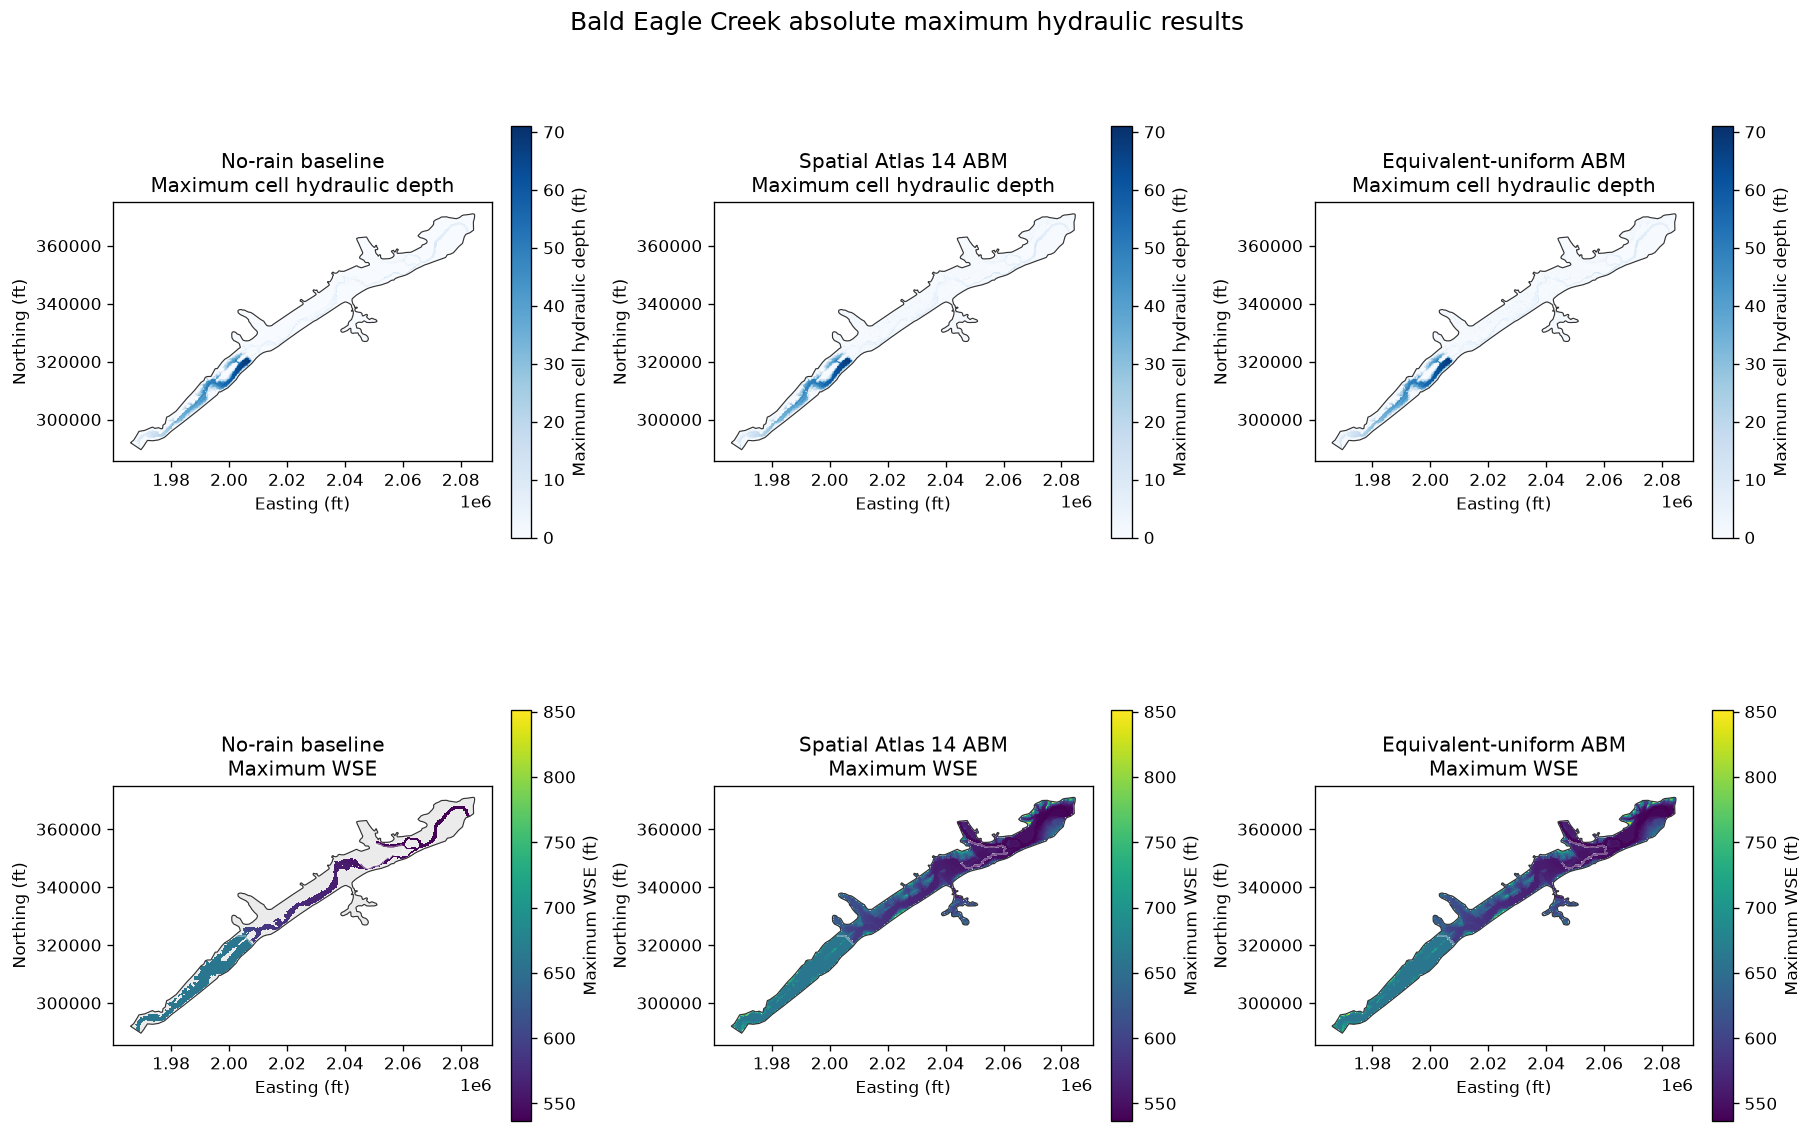

In [17]:
depth_vmax = max(
    float(frame["maximum_cell_hydraulic_depth"].max())
    for frame in scenario_hydraulics.values()
)
wse_values = np.concatenate(
    [
        frame["maximum_water_surface"].dropna().to_numpy(dtype=float)
        for frame in scenario_hydraulics.values()
    ]
)
wse_vmin = float(np.nanmin(wse_values))
wse_vmax = float(np.nanmax(wse_values))

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
for column, scenario in enumerate(SCENARIO_ORDER):
    frame = scenario_hydraulics[scenario]
    frame.plot(
        ax=axes[0, column],
        column="maximum_cell_hydraulic_depth",
        cmap="Blues",
        vmin=0.0,
        vmax=depth_vmax,
        linewidth=0,
        legend=True,
        legend_kwds={
            "label": "Maximum cell hydraulic depth (ft)",
            "shrink": 0.72,
        },
    )
    frame.plot(
        ax=axes[1, column],
        column="maximum_water_surface",
        cmap="viridis",
        vmin=wse_vmin,
        vmax=wse_vmax,
        linewidth=0,
        legend=True,
        missing_kwds={"color": "0.92", "label": "Dry cell"},
        legend_kwds={"label": "Maximum WSE (ft)", "shrink": 0.72},
    )
    for row, label in [(0, "Maximum cell hydraulic depth"), (1, "Maximum WSE")]:
        mesh_areas.boundary.plot(ax=axes[row, column], color="0.2", linewidth=0.7)
        axes[row, column].set_title(f"{scenario}\n{label}")
        axes[row, column].set_xlabel("Easting (ft)")
        axes[row, column].set_ylabel("Northing (ft)")
        axes[row, column].set_aspect("equal")

fig.suptitle("Bald Eagle Creek absolute maximum hydraulic results", fontsize=15)
plt.show()


## 10. Quantify and map modeled hydraulic differences

The pairwise comparisons are spatial-minus-baseline, uniform-minus-baseline, and spatial-minus-uniform. Maximum cell hydraulic-depth differences are evaluated over all 18,066 aligned cells, including newly wetted areas. Maximum-WSE differences are evaluated only where both scenarios are wet (`maximum cell hydraulic depth > 0.01 ft` in each scenario); NaN arithmetic enforces that common-wet intersection. The table reports the common-wet cell count and area for every comparison and uses the 0.01 ft reporting threshold to count meaningfully changed cells and area. Full unthresholded minima, maxima, and means are retained within each stated comparison domain.

The focused maps center on the cell with the largest combined spatial-minus-uniform signal: hydraulic depth is eligible at every aligned cell, while WSE contributes only where the spatial and uniform scenarios are both wet. The 20,000 ft square review window exposes the strongest calculated spatial-pattern response rather than relying only on whole-domain overview maps.

In [18]:
hydraulic_grid = mesh_cells.copy()
for scenario in SCENARIO_ORDER:
    slug = SCENARIO_SLUG[scenario]
    values = scenario_hydraulics[scenario][
        [
            "mesh_name",
            "cell_id",
            "maximum_cell_hydraulic_depth",
            "maximum_water_surface",
        ]
    ].rename(
        columns={
            "maximum_cell_hydraulic_depth": f"maximum_cell_hydraulic_depth_{slug}",
            "maximum_water_surface": f"maximum_wse_{slug}",
        }
    )
    hydraulic_grid = hydraulic_grid.merge(
        values,
        on=["mesh_name", "cell_id"],
        how="inner",
    )
hydraulic_grid = gpd.GeoDataFrame(
    hydraulic_grid,
    geometry="geometry",
    crs=mesh_cells.crs,
)

PAIR_SPECS = [
    ("spatial_minus_baseline", "Spatial - baseline", "spatial", "baseline"),
    ("uniform_minus_baseline", "Uniform - baseline", "uniform", "baseline"),
    ("spatial_minus_uniform", "Spatial - uniform", "spatial", "uniform"),
]
for key, _, minuend, subtrahend in PAIR_SPECS:
    hydraulic_grid[f"hydraulic_depth_{key}"] = (
        hydraulic_grid[f"maximum_cell_hydraulic_depth_{minuend}"]
        - hydraulic_grid[f"maximum_cell_hydraulic_depth_{subtrahend}"]
    )
    common_wet = (
        hydraulic_grid[f"maximum_cell_hydraulic_depth_{minuend}"]
        > REPORTING_THRESHOLD_FT
    ) & (
        hydraulic_grid[f"maximum_cell_hydraulic_depth_{subtrahend}"]
        > REPORTING_THRESHOLD_FT
    )
    hydraulic_grid[f"common_wet_{key}"] = common_wet
    hydraulic_grid[f"wse_{key}"] = (
        hydraulic_grid[f"maximum_wse_{minuend}"]
        - hydraulic_grid[f"maximum_wse_{subtrahend}"]
    ).where(common_wet)
    assert hydraulic_grid.loc[~common_wet, f"wse_{key}"].isna().all()

difference_records = []
for key, label, _, _ in PAIR_SPECS:
    common_wet = hydraulic_grid[f"common_wet_{key}"]
    common_wet_index = hydraulic_grid.index[common_wet]
    common_wet_area_acres = float(
        hydraulic_grid.loc[common_wet_index].geometry.area.sum() / 43560.0
    )
    for result_type in ("hydraulic_depth", "wse"):
        values = hydraulic_grid[f"{result_type}_{key}"].dropna()
        if result_type == "hydraulic_depth":
            comparison_domain = "all aligned cells"
            assert len(values) == len(hydraulic_grid)
        else:
            comparison_domain = "cells wet in both scenarios"
            assert len(values) == int(common_wet.sum())
        changed = values.abs() >= REPORTING_THRESHOLD_FT
        changed_index = values.index[changed]
        difference_records.append(
            {
                "comparison": label,
                "result": (
                    "maximum cell hydraulic depth"
                    if result_type == "hydraulic_depth"
                    else "maximum WSE (common-wet only)"
                ),
                "comparison domain": comparison_domain,
                "evaluated cells": len(values),
                "evaluated area (acres)": float(
                    hydraulic_grid.loc[values.index].geometry.area.sum() / 43560.0
                ),
                "common-wet cells": int(common_wet.sum()),
                "common-wet area (acres)": common_wet_area_acres,
                "minimum difference (ft)": float(values.min()),
                "mean difference (ft)": float(values.mean()),
                "maximum difference (ft)": float(values.max()),
                "95th percentile absolute difference (ft)": float(
                    values.abs().quantile(0.95)
                ),
                "cells |difference| >= 0.01 ft": int(changed.sum()),
                "area |difference| >= 0.01 ft (acres)": float(
                    hydraulic_grid.loc[changed_index].geometry.area.sum() / 43560.0
                ),
            }
        )

difference_summary_df = pd.DataFrame(difference_records)
display(difference_summary_df.round(4))

spatial_uniform_signal = pd.concat(
    [
        hydraulic_grid["hydraulic_depth_spatial_minus_uniform"].abs(),
        hydraulic_grid["wse_spatial_minus_uniform"].abs(),
    ],
    axis=1,
).max(axis=1, skipna=True)
assert float(spatial_uniform_signal.max()) > 0.0
focus_index = spatial_uniform_signal.idxmax()
focus_center = hydraulic_grid.loc[focus_index].geometry.centroid
FOCUS_HALF_WIDTH_FT = 10000.0
focus_bounds = (
    focus_center.x - FOCUS_HALF_WIDTH_FT,
    focus_center.y - FOCUS_HALF_WIDTH_FT,
    focus_center.x + FOCUS_HALF_WIDTH_FT,
    focus_center.y + FOCUS_HALF_WIDTH_FT,
)

top_cell_columns = [
    "mesh_name",
    "cell_id",
    "hydraulic_depth_spatial_minus_baseline",
    "hydraulic_depth_uniform_minus_baseline",
    "hydraulic_depth_spatial_minus_uniform",
    "wse_spatial_minus_baseline",
    "wse_uniform_minus_baseline",
    "wse_spatial_minus_uniform",
    "common_wet_spatial_minus_uniform",
]
top_cells = hydraulic_grid.loc[
    spatial_uniform_signal.nlargest(12).index,
    top_cell_columns + ["geometry"],
].copy()
top_cells["easting_ft"] = top_cells.geometry.centroid.x
top_cells["northing_ft"] = top_cells.geometry.centroid.y
display(top_cells.drop(columns="geometry").round(4))


,comparison,result,comparison domain,evaluated cells,evaluated area (acres),common-wet cells,common-wet area (acres),minimum difference (ft),mean difference (ft),maximum difference (ft),95th percentile absolute difference (ft),cells |difference| >= 0.01 ft,area |difference| >= 0.01 ft (acres)
0,Spatial - baseline,maximum cell hydraulic depth,all aligned cells,18066,26400.8454,6029,8618.2125,-0.2872,0.8148,17.8177,2.2810,17527,25621.8827
1,Spatial - baseline,maximum WSE (common-wet only),cells wet in both scenarios,6029,8618.2125,6029,8618.2125,-0.3069,0.3487,4.6980,1.3233,6004,8582.2332
2,Uniform - baseline,maximum cell hydraulic depth,all aligned cells,18066,26400.8454,6029,8618.2125,-0.2875,0.8161,17.7504,2.2846,17518,25608.9695
3,Uniform - baseline,maximum WSE (common-wet only),cells wet in both scenarios,6029,8618.2125,6029,8618.2125,-0.3072,0.3476,4.6383,1.3226,6004,8582.2332
4,Spatial - uniform,maximum cell hydraulic depth,all aligned cells,18066,26400.8454,18066,26400.8454,-0.1924,-0.0013,0.1173,0.0284,4713,7005.5206
5,Spatial - uniform,maximum WSE (common-wet only),cells wet in both scenarios,18066,26400.8454,18066,26400.8454,-0.4589,-0.0030,0.3230,0.0666,8713,12911.2766


,mesh_name,cell_id,hydraulic_depth_spatial_minus_baseline,hydraulic_depth_uniform_minus_baseline,hydraulic_depth_spatial_minus_uniform,wse_spatial_minus_baseline,wse_uniform_minus_baseline,wse_spatial_minus_uniform,common_wet_spatial_minus_uniform,easting_ft,northing_ft
4008,BaldEagleCr,4008,3.9215,4.0187,-0.0972,NaN,NaN,-0.4589,True,2.046750e+06,355250.0000
4009,BaldEagleCr,4009,4.6744,4.8152,-0.1408,NaN,NaN,-0.4034,True,2.047000e+06,355250.0000
3913,BaldEagleCr,3913,5.3426,5.5292,-0.1866,NaN,NaN,-0.3893,True,2.046500e+06,355500.0000
3615,BaldEagleCr,3615,3.7456,3.8286,-0.0831,NaN,NaN,-0.3591,True,2.045750e+06,356250.0000
8912,BaldEagleCr,8912,3.6656,3.8447,-0.1791,NaN,NaN,-0.3577,True,2.026500e+06,338250.0000
8913,BaldEagleCr,8913,2.7159,2.8778,-0.1619,NaN,NaN,-0.3577,True,2.026750e+06,338250.0000
8968,BaldEagleCr,8968,3.4981,3.6905,-0.1924,NaN,NaN,-0.3577,True,2.026500e+06,338000.0000
8969,BaldEagleCr,8969,2.6121,2.7228,-0.1107,NaN,NaN,-0.3577,True,2.026750e+06,338000.0000
4380,BaldEagleCr,4380,2.5839,2.6862,-0.1023,NaN,NaN,-0.3402,True,2.047971e+06,354271.0977
17002,BaldEagleCr,17002,2.2777,2.2599,0.0178,NaN,NaN,0.3230,True,1.972250e+06,296250.0000


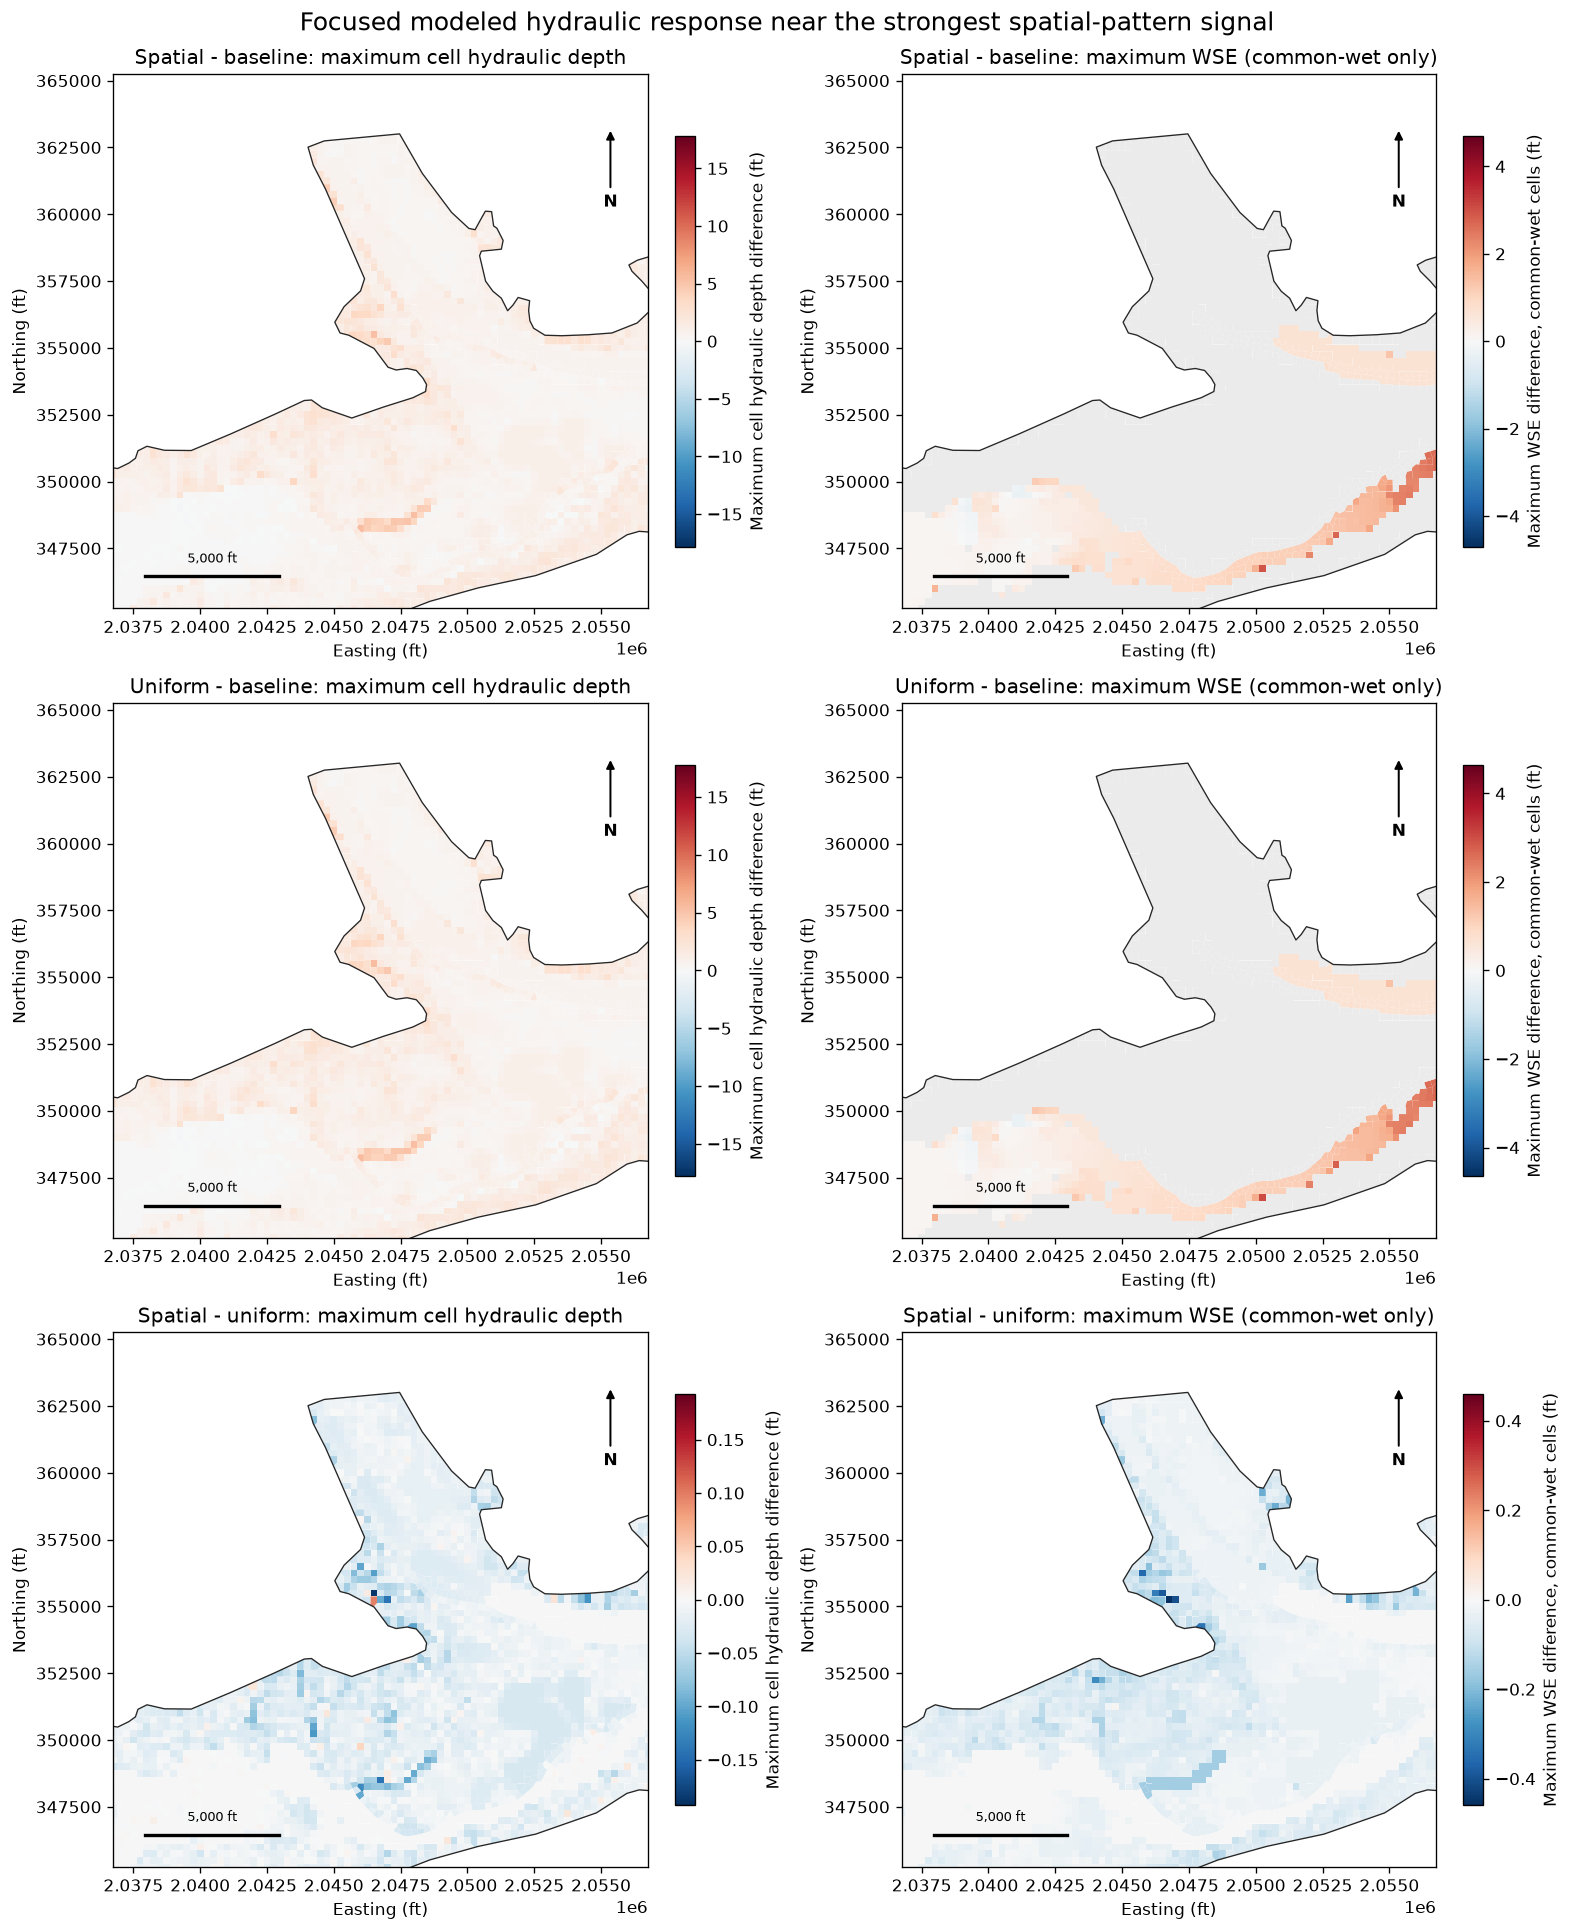

In [19]:
def plot_focused_difference(ax, frame, column, title, colorbar_label):
    values = frame[column].dropna()
    max_abs = max(float(values.abs().max()), 0.001)
    frame.plot(
        ax=ax,
        column=column,
        cmap="RdBu_r",
        norm=TwoSlopeNorm(vmin=-max_abs, vcenter=0.0, vmax=max_abs),
        linewidth=0,
        legend=True,
        missing_kwds={"color": "0.92", "label": "Outside comparison domain"},
        legend_kwds={"label": colorbar_label, "shrink": 0.72},
    )
    mesh_areas.boundary.plot(ax=ax, color="0.15", linewidth=0.8)
    ax.set_xlim(focus_bounds[0], focus_bounds[2])
    ax.set_ylim(focus_bounds[1], focus_bounds[3])
    ax.set_title(title)
    ax.set_xlabel("Easting (ft)")
    ax.set_ylabel("Northing (ft)")
    ax.set_aspect("equal")
    ax.annotate(
        "N",
        xy=(0.93, 0.90),
        xytext=(0.93, 0.76),
        xycoords="axes fraction",
        textcoords="axes fraction",
        ha="center",
        va="center",
        fontweight="bold",
        arrowprops={"arrowstyle": "-|>", "color": "black", "lw": 1.2},
    )
    scale_y = focus_bounds[1] + 0.06 * (focus_bounds[3] - focus_bounds[1])
    scale_x = focus_bounds[0] + 0.06 * (focus_bounds[2] - focus_bounds[0])
    ax.plot([scale_x, scale_x + 5000], [scale_y, scale_y], color="black", lw=2)
    ax.text(
        scale_x + 2500,
        scale_y + 0.02 * (focus_bounds[3] - focus_bounds[1]),
        "5,000 ft",
        ha="center",
        va="bottom",
        fontsize=8,
    )


fig, axes = plt.subplots(3, 2, figsize=(13, 16), constrained_layout=True)
for row, (key, label, _, _) in enumerate(PAIR_SPECS):
    plot_focused_difference(
        axes[row, 0],
        hydraulic_grid,
        f"hydraulic_depth_{key}",
        f"{label}: maximum cell hydraulic depth",
        "Maximum cell hydraulic depth difference (ft)",
    )
    plot_focused_difference(
        axes[row, 1],
        hydraulic_grid,
        f"wse_{key}",
        f"{label}: maximum WSE (common-wet only)",
        "Maximum WSE difference, common-wet cells (ft)",
    )

fig.suptitle(
    "Focused modeled hydraulic response near the strongest spatial-pattern signal",
    fontsize=15,
)
plt.show()


## 11. Engineering interpretation and limitations

This notebook demonstrates a controlled **hydraulic evaluation** of a spatial Atlas 14 rain-on-grid method. The absolute results, pairwise differences, changed-cell counts, and changed areas are calculated model outputs for professional review. They do **not** establish net benefits, adverse impacts, regulatory significance, design adequacy, or causal proof.

Important constraints remain:

- Atlas 14 precipitation-frequency depths and the centered ABM temporal pattern define a synthetic design storm, not an observed event.
- The inherited upstream inflow, normal-depth outlets, terrain, infiltration, and computational settings are held fixed to isolate precipitation representation; they are not independently established as coincident 100-year boundary conditions.
- Sayers Dam Gate #1 remains fixed at the inherited 2.0 ft schedule because observed design-storm gate operations are unavailable. Gate-operation sensitivity requires a separate approved analysis.
- The equivalent-uniform scenario preserves the spatial scenario's mesh-area-weighted rate and total depth. Spatial-minus-uniform differences therefore isolate modeled sensitivity to rainfall distribution within the limits of cell sampling and interpolation.
- Maximum-WSE statistics and differences exclude dry cells. Pairwise WSE values represent only cells wet in both scenarios; maximum cell hydraulic-depth differences retain all aligned cells and therefore capture newly wetted areas.
- Cells exceeding 0.01 ft are screening locations for engineering review, not automatic benefit or impact classifications.

In [20]:
completion_summary = pd.DataFrame(
    [
        {
            "check": "HEC-RAS plans completed without parsed errors",
            "result": bool(
                compute_diagnostics_df["completed"].all()
                and (compute_diagnostics_df["errors"] == 0).all()
            ),
        },
        {
            "check": "Spatial and uniform forcing span plan",
            "result": bool(forcing_times[-1] == pd.Timestamp(SIM_END)),
        },
        {
            "check": "Post-storm rates are exactly zero",
            "result": bool(
                np.all(post_storm_rate[np.isfinite(post_storm_rate)] == 0.0)
                and np.all(uniform_tail[np.isfinite(uniform_tail)] == 0.0)
            ),
        },
        {
            "check": "Spatial and uniform mesh-weighted totals match",
            "result": bool(
                np.isclose(spatial_mesh_total_in, uniform_mesh_total_in, atol=1e-6)
            ),
        },
        {
            "check": "All 2D cells included in hydraulic comparison",
            "result": bool(len(hydraulic_grid) == len(mesh_cells)),
        },
        {
            "check": "Absolute WSE is masked outside each scenario wet area",
            "result": bool(
                all(
                    frame.loc[
                        frame["maximum_cell_hydraulic_depth"]
                        <= REPORTING_THRESHOLD_FT,
                        "maximum_water_surface",
                    ].isna().all()
                    for frame in scenario_hydraulics.values()
                )
            ),
        },
        {
            "check": "Pairwise WSE uses common-wet intersections",
            "result": bool(
                all(
                    hydraulic_grid.loc[
                        ~hydraulic_grid[f"common_wet_{key}"],
                        f"wse_{key}",
                    ].isna().all()
                    and hydraulic_grid[f"wse_{key}"].notna().sum()
                    == hydraulic_grid[f"common_wet_{key}"].sum()
                    for key, _, _, _ in PAIR_SPECS
                )
            ),
        },
    ]
)
assert completion_summary["result"].all()
display(completion_summary)


,check,result
0,HEC-RAS plans completed without parsed errors,True
1,Spatial and uniform forcing span plan,True
2,Post-storm rates are exactly zero,True
3,Spatial and uniform mesh-weighted totals match,True
4,All 2D cells included in hydraulic comparison,True
5,Absolute WSE is masked outside each scenario w...,True
6,Pairwise WSE uses common-wet intersections,True
